In [142]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import seaborn as sns

# import shap
import warnings

# shap.initjs()

warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [ ]:
# Load dataset
nri_hpi_loaded = pd.read_csv(
    "../../02_processed_data/nri_hpi_data_full.csv"
).reset_index(drop=True)
nri_dictionary_2023 = pd.read_csv(
    "../../01_original_data/NRI/2023/NRIDataDictionary.csv"
)
nri_dictionary_2021 = pd.read_csv(
    "../../01_original_data/NRI/2021/NRIDataDictionary.csv"
)
nri_dictionary_2020 = pd.read_csv(
    "../../01_original_data/NRI/2020/NRIDataDictionary.csv"
)

nri_dictionary = pd.concat(
    [nri_dictionary_2020, nri_dictionary_2021, nri_dictionary_2023]
)
nri_dictionary.columns = [
    re.sub(r"\s+", "_", c.strip().lower()) for c in nri_dictionary.columns
]
nri_dictionary["field_name"] = nri_dictionary["field_name"].apply(lambda x: x.lower())

nri_dictionary = nri_dictionary.drop_duplicates(subset=["field_name"])
nri_dictionary["field_alias"] = nri_dictionary["field_alias"].apply(
    lambda x: " ".join([y[:3] for y in x.split()]) if len(x) > 50 else x
)

nri_hpi_loaded["hpi_perc_change"] = (
    nri_hpi_loaded["hpi_change"] / nri_hpi_loaded["index_prev"]
)
targets = nri_hpi_loaded[["hpi_perc_change", "index_nsa"]]

# drop_columns = [x for x in nri_hpi_loaded.columns if "alrb" not in x and "eal" not in x]
# drop_columns = [
#         "Unnamed: 0",
#         "county_fips5",
#         "county",
#         "oid_",
#         "cbsa_code",
#         "place_id",
#         "index_prev",
#         "hpi_change",
#         "index_nsa",
#     ]

pick_columns = [
    x for x in nri_hpi_loaded.columns if "alrb" in x
]  # or "alra" in x or "alrp" in x] # Expected Annual Loss Rate - Building for every hazard
pick_columns.extend(
    [
        # "statefips",
        # "stcofips",
        # "nri_ver",
        # "population",
        # "risk_score",
        # "eal_score",
        # "eal_valt",
        # "eal_valp",
        # "cfld_afreq",
        # "alr_valb",  # Expected Annual Loss Rate - Building - Composite (MOST IMPORTANT)
        "alr_valp",  # Expected Annual Loss Rate - Population - Composite
        "alr_vala",  # Expected Annual Loss Rate - Agriculture - Composite
    ]
)

# print(len(nri_hpi))
# nri_hpi = nri_hpi.drop(columns=drop_columns).reset_index(drop=True)

nri_hpi = nri_hpi_loaded[pick_columns]
years = nri_hpi_loaded[nri_hpi_loaded["yr"].isin([2019, 2020, 2021, 2022])]
cal = nri_hpi_loaded[nri_hpi_loaded["stateabbrv"] == "CA"]
cal

,Unnamed: 0,oid_,nri_id,state,stateabbrv,statefips,county,countytype,countyfips,stcofips,...,resl_npctl,cbsa_code,county_fips5,place_name,place_id,yr,index_nsa,index_prev,hpi_change,hpi_perc_change
59,99,191,C06007,California,CA,6,Butte,County,7,6007,...,NaN,17020,6007,"Chico, CA",17020,2023,350.775000,356.127500,-5.352500,-0.015030
60,102,196,C06017,California,CA,6,El Dorado,County,17,6017,...,NaN,40900,6017,"Sacramento-Roseville-Folsom, CA",40900,2023,370.787500,375.366667,-4.579167,-0.012199
61,103,197,C06019,California,CA,6,Fresno,County,19,6019,...,NaN,23420,6019,"Fresno, CA",23420,2023,357.270000,347.752500,9.517500,0.027369
62,105,200,C06025,California,CA,6,Imperial,County,25,6025,...,NaN,20940,6025,"El Centro, CA",20940,2023,313.435000,295.362500,18.072500,0.061188
63,107,202,C06029,California,CA,6,Kern,County,29,6029,...,NaN,12540,6029,"Bakersfield-Delano, CA",12540,2023,320.922500,312.125000,8.797500,0.028186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2465,4442,1304,C06101,California,CA,6,Sutter,County,101,6101,...,59.898154,49700,6101,"Yuba City, CA",49700,2020,272.410000,255.287500,17.122500,0.067071
2466,4444,1307,C06107,California,CA,6,Tulare,County,107,6107,...,12.826225,47300,6107,"Visalia, CA",47300,2020,226.935000,215.180000,11.755000,0.054629
2467,4446,1309,C06111,California,CA,6,Ventura,County,111,6111,...,50.763845,37100,6111,"Oxnard-Thousand Oaks-Ventura, CA",37100,2020,314.793750,298.585000,16.208750,0.054285
2468,4447,1310,C06113,California,CA,6,Yolo,County,113,6113,...,48.535964,40900,6113,"Sacramento-Roseville-Folsom, CA",40900,2020,288.819167,271.305833,17.513333,0.064552


In [161]:
nri_dictionary

,sort,field_name,field_alias,type,length,relevant_layer,metric_type,version,version_date
0,1,objectid,OBJECTID,Integer,4.0,NaN,NaN,NaN,NaN
1,2,shape,Shape,Geometry,NaN,NaN,NaN,NaN,NaN
2,3,shape_length,Shape_Length,Double,8.0,NaN,NaN,NaN,NaN
3,4,shape_area,Shape_Area,Double,8.0,NaN,NaN,NaN,NaN
4,5,state,State Name,String,250.0,All,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
462,463,wntw_alrb,Win Wea - Exp Ann Los Rat - Bui,Double,8.0,Winter Weather,Expected Annual Loss Rate - Building,1.19.0,March 2023
463,464,wntw_alrp,Win Wea - Exp Ann Los Rat - Pop,Double,8.0,Winter Weather,Expected Annual Loss Rate - Population,1.19.0,March 2023
464,465,wntw_alra,Win Wea - Exp Ann Los Rat - Agr,Double,8.0,Winter Weather,Expected Annual Loss Rate - Agriculture,1.19.0,March 2023
465,466,wntw_alr_npctl,Win Wea - Exp Ann Los Rat - Nat Per,Double,8.0,Winter Weather,National Percentile,1.19.0,March 2023


In [162]:
nri_hpi = nri_hpi.select_dtypes(exclude=["object"])
nri_hpi

,avln_alrb,cfld_alrb,cwav_alrb,erqk_alrb,hail_alrb,hwav_alrb,hrcn_alrb,istm_alrb,lnds_alrb,ltng_alrb,rfld_alrb,swnd_alrb,trnd_alrb,tsun_alrb,vlcn_alrb,wfir_alrb,wntw_alrb,alr_valp,alr_vala
0,NaN,NaN,0.0,0.000017,1.495284e-05,2.020631e-07,0.000093,2.326986e-07,4.932440e-07,6.483509e-07,0.000020,0.000020,0.000141,NaN,NaN,1.115029e-06,2.687716e-07,0.000004,0.002883
1,NaN,0.000003,0.0,0.000008,2.227459e-08,3.183949e-09,0.003778,5.592036e-09,1.882903e-07,2.248002e-06,0.000054,0.000002,0.000079,NaN,NaN,4.890994e-05,1.268231e-09,0.000006,0.014643
2,NaN,NaN,0.0,0.000055,2.085964e-05,2.020631e-07,0.000056,1.061468e-05,1.429957e-06,3.881165e-06,0.000006,0.000023,0.000277,NaN,NaN,1.304250e-06,9.014679e-07,0.000007,0.001818
3,NaN,NaN,0.0,0.000049,7.643006e-06,2.020631e-07,0.000024,1.019435e-05,5.757700e-07,3.999302e-06,0.000004,0.000017,0.000310,NaN,NaN,6.405546e-07,5.268425e-07,0.000007,0.000402
4,NaN,NaN,0.0,0.000041,7.472163e-06,1.683859e-07,0.000043,1.080614e-07,5.788750e-06,3.355571e-06,0.000003,0.000007,0.000293,NaN,NaN,3.542235e-07,2.387269e-07,0.000009,0.000955
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [163]:
# Train/test split
X = nri_hpi
y = targets["index_nsa"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
# print(classification_report(y_test, model.predict(X_test)))

RandomForestRegressor(random_state=42)

,index,0,field_name
field_alias,,,
Strong Wind - Expected Annual Loss Rate - Building,swnd_alrb,0.210264,swnd_alrb
Tornado - Expected Annual Loss Rate - Building,trnd_alrb,0.174503,trnd_alrb
Hurricane - Expected Annual Loss Rate - Building,hrcn_alrb,0.142169,hrcn_alrb
Earthquake - Expected Annual Loss Rate - Building,erqk_alrb,0.067695,erqk_alrb
Wildfire - Expected Annual Loss Rate - Building,wfir_alrb,0.053856,wfir_alrb
Lightning - Expected Annual Loss Rate - Building,ltng_alrb,0.051601,ltng_alrb
Exp Ann Los Rat - Agr - Com,alr_vala,0.050430,alr_vala
Hail - Expected Annual Loss Rate - Building,hail_alrb,0.044524,hail_alrb
Expected Annual Loss Rate - Population - Composite,alr_valp,0.043343,alr_valp


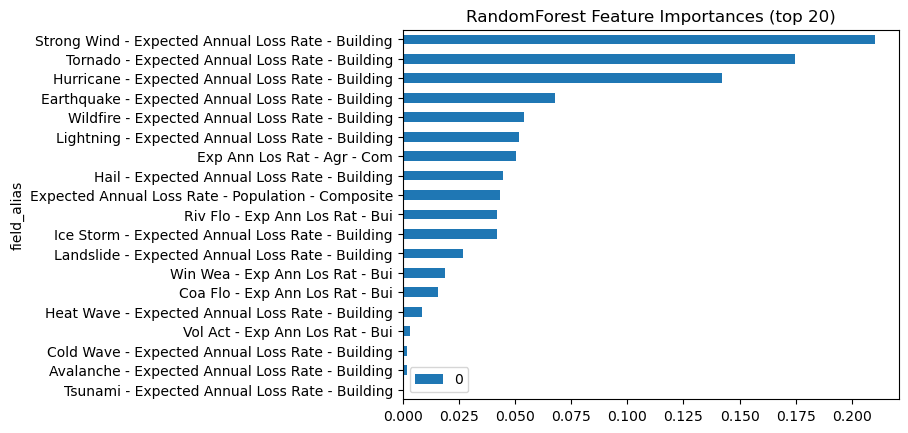

In [164]:
# ---- Global: Randomforest feature importances ----
rf_importance = pd.Series(
    getattr(model, "feature_importances_", None),
    index=getattr(
        X_train, "columns", range(len(getattr(model, "feature_importances_", [])))
    ),
)


def plot_importance(rf_importance, title):
    rf_importance = rf_importance.sort_values(ascending=False)

    importance = pd.DataFrame(rf_importance).reset_index()

    importance = importance.merge(
        nri_dictionary[["field_name", "field_alias"]],
        left_on="index",
        right_on="field_name",
        how="left",
    )
    importance["field_alias"] = importance["field_alias"].fillna(importance["index"])
    importance = importance.set_index("field_alias")

    display(importance.head(20))

    # plt.figure(figsize=(20, 20))
    importance.head(20).iloc[::-1].plot(kind="barh")
    plt.title(title)
    # plt.tight_layout()
    plt.show()


plot_importance(rf_importance, "RandomForest Feature Importances (top 20)")

In [148]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RandomForestRegressor Performance")
print(f"R² Score:              {r2:.3f}")
print(f"Mean Absolute Error:   {mae:.3f}")
print(f"Mean Squared Error:    {mse:.3f}")
print(f"Root Mean Squared Error: {rmse:.3f}")

RandomForestRegressor Performance
R² Score:              0.324
Mean Absolute Error:   45.587
Mean Squared Error:    3831.154
Root Mean Squared Error: 61.896


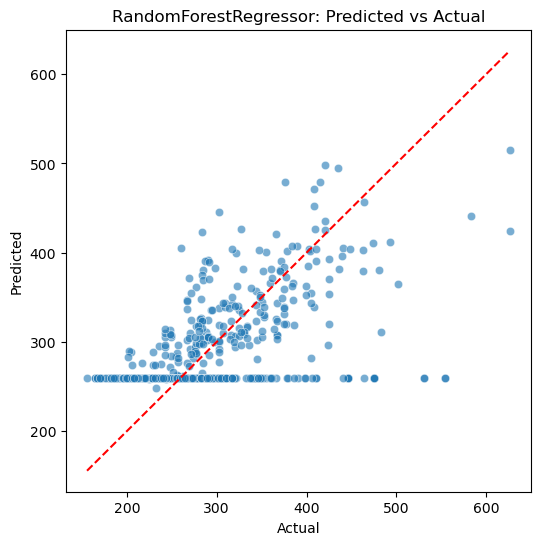

In [129]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("RandomForestRegressor: Predicted vs Actual")
plt.show()

## With HPI Percent Change

In [149]:
# Train/test split
y = targets["hpi_perc_change"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

,index,0,field_name
field_alias,,,
Expected Annual Loss Rate - Building - Composite,alr_valb,0.544532,alr_valb
Hurricane - Expected Annual Loss Rate - Building,hrcn_alrb,0.105678,hrcn_alrb
Tornado - Expected Annual Loss Rate - Building,trnd_alrb,0.073986,trnd_alrb
Earthquake - Expected Annual Loss Rate - Building,erqk_alrb,0.061282,erqk_alrb
Expected Annual Loss Rate - Population - Composite,alr_valp,0.029643,alr_valp
Riv Flo - Exp Ann Los Rat - Bui,rfld_alrb,0.027677,rfld_alrb
Wildfire - Expected Annual Loss Rate - Building,wfir_alrb,0.024305,wfir_alrb
Hail - Expected Annual Loss Rate - Building,hail_alrb,0.019569,hail_alrb
Ice Storm - Expected Annual Loss Rate - Building,istm_alrb,0.018756,istm_alrb


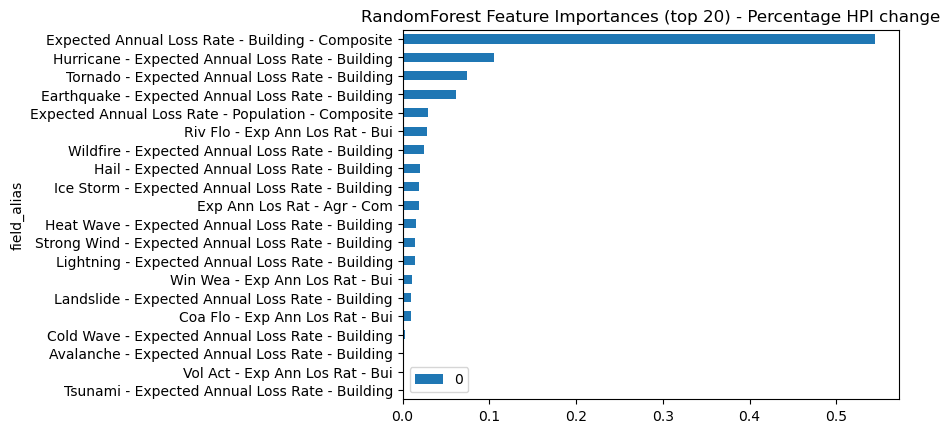

In [150]:
rf_importance = pd.Series(
    getattr(model, "feature_importances_", None),
    index=getattr(
        X_train, "columns", range(len(getattr(model, "feature_importances_", [])))
    ),
)
plot_importance(
    rf_importance, "RandomForest Feature Importances (top 20) - Percentage HPI change"
)

In [151]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("📊 RandomForestRegressor Performance")
print(f"R² Score:              {r2:.3f}")
print(f"Mean Absolute Error:   {mae:.3f}")
print(f"Mean Squared Error:    {mse:.3f}")
print(f"Root Mean Squared Error: {rmse:.3f}")

📊 RandomForestRegressor Performance
R² Score:              0.196
Mean Absolute Error:   0.034
Mean Squared Error:    0.002
Root Mean Squared Error: 0.044


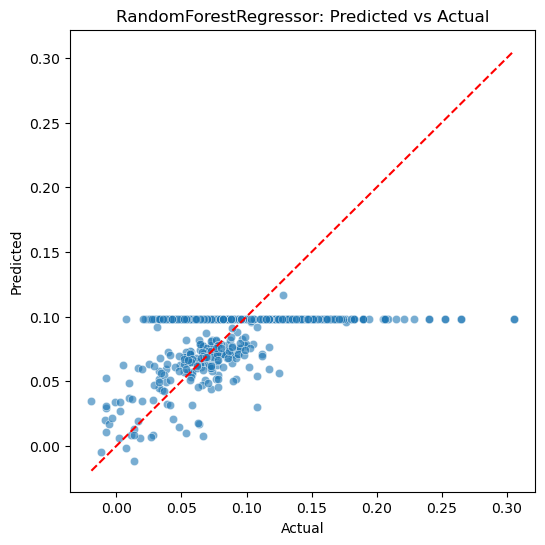

In [152]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("RandomForestRegressor: Predicted vs Actual")
plt.show()

## PCA

In [134]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [135]:
nri_hpi = nri_hpi_loaded.select_dtypes(exclude=["object"]).fillna(0)
drop_columns = [
    "OID_",
    "STATEFIPS",
    "COUNTYFIPS",
    "STCOFIPS",
    "NRI_VER",
]
nri_hpi = nri_hpi.drop(
    columns=[x.lower() for x in drop_columns],
    axis=1,
)
# drop client's columns
# nri_hpi = nri_hpi.drop(columns=pick_columns, axis=1)

scaler = StandardScaler()
nri_hpi_model = scaler.fit_transform(nri_hpi)
len(nri_hpi.columns)

411

In [165]:
pca = PCA(n_components=40)  # keep 2 principal components
X_pca = pca.fit_transform(nri_hpi_model)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.15598287 0.0962881  0.05856592 0.04100016 0.03345984 0.02876313
 0.02312511 0.02295133 0.02176769 0.01726307 0.01627812 0.01494256
 0.01451811 0.01333328 0.01233369 0.01156457 0.0108291  0.01043389
 0.00956327 0.00943204 0.00872582 0.00837032 0.00801427 0.00784911
 0.00747244 0.00722299 0.00700057 0.00678714 0.006676   0.00641225
 0.00615628 0.00595948 0.00583431 0.00555655 0.00538173 0.00525575
 0.00523999 0.00512084 0.00479797 0.00477574]
Cumulative: 0.7510054073983229


In [166]:
pca_df = pd.DataFrame(
    X_pca  # , columns=["PC1", "PC2", "PC3", "PC4","PC5","PC6","PC7","PC8","PC9","PC10","PC11","PC12","PC13","PC14","PC15","PC16","PC17","PC18","PC19","PC20","PC21","PC22","PC23","PC24","PC25",], index=nri_hpi.index
)
pca_df = pd.concat([pca_df, nri_hpi_loaded[["stcofips"]]], axis=1)
pca_df

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,stcofips
0,2.038790,6.259572,-1.150574,1.606757,-1.660675,1.006920,-1.281122,-1.653346,-1.030383,-0.086826,...,0.720244,-1.076571,0.143363,-0.111154,0.667291,1.653639,0.518568,0.724750,-0.402801,1001
1,15.265427,5.908760,-5.257090,15.862141,1.054590,-2.304573,1.822471,-1.805364,-1.943606,-3.853143,...,-2.010935,1.756545,-2.160292,2.545831,-5.344736,0.001384,1.376386,-0.415419,0.315390,1003
2,1.404261,7.907764,-0.599507,1.711106,-1.461860,0.863916,-1.028941,-1.488676,-1.331137,1.176170,...,0.297610,-0.469543,1.036216,-0.677033,-0.060624,1.667511,-1.067640,0.646837,-1.169730,1007
3,4.173162,8.382538,-1.410701,0.094192,-1.846543,1.370317,-0.185925,-1.100452,-0.121207,-0.310826,...,-0.135865,0.163757,0.228361,-0.080893,-0.805804,3.133352,-0.393098,-0.204442,-0.770427,1009
4,6.553325,7.358741,-1.693787,0.083484,-0.904247,1.776064,-0.954524,-1.484912,-1.223259,-0.198933,...,0.508540,-0.666855,-0.466975,-1.063075,-0.838019,3.234357,-0.369192,-0.351662,-0.810290,1015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3112,-4.512912,-3.463155,-1.005366,-2.249212,0.726694,-0.544772,1.411109,0.827807,-0.203276,0.135034,...,-0.521021,-0.514739,-0.750820,0.474040,0.376464,-0.304769,1.087636,0.448587,1.297307,55131
3113,-0.011461,-6.960891,-2.774899,-3.823383,2.104470,-0.667797,0.894435,1.039282,-0.587552,-0.997986,...,-1.527944,-0.809999,0.097010,0.939982,-0.195456,-1.079828,0.970713,-0.365558,0.561693,55133
3114,-4.085638,-4.042450,-1.927291,-3.017430,1.180020,-0.639808,2.368754,1.264677,-0.969427,-0.848331,...,1.402555,-0.305991,-1.008414,0.353648,0.533012,-0.111144,1.781958,-0.167954,2.877306,55139
3115,-4.444326,-2.919571,0.009263,-3.319747,2.059172,-4.099682,3.701747,3.810205,0.624820,-0.880140,...,0.361649,0.039429,-1.365225,1.405250,-1.657719,2.463055,0.197966,-1.968720,-0.210326,56021


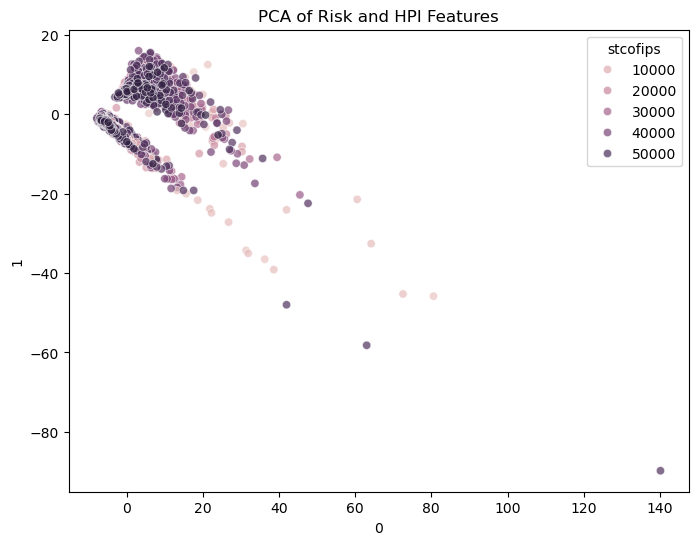

In [167]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x=0, y=1, hue="stcofips", alpha=0.7)
plt.title("PCA of Risk and HPI Features")
plt.show()

In [168]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=nri_hpi.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
)
print(loadings)

ValueError: Shape of passed values is (411, 40), indices imply (19, 40)

Explained variance ratio: [0.15598287 0.0962881  0.05856592 0.04100016 0.03345984 0.02876313
 0.02312511 0.02295133 0.02176769 0.01726307 0.01627812 0.01494256
 0.01451811 0.01333328 0.01233369 0.01156457 0.0108291  0.01043389
 0.00956327 0.00943204 0.00872582 0.00837032 0.00801427 0.00784911
 0.00747244 0.00722299 0.00700057 0.00678714 0.006676   0.00641225
 0.00615628 0.00595948 0.00583431 0.00555655 0.00538173 0.00525575
 0.00523999 0.00512084 0.00479797 0.00477574]
Cumulative variance explained: [0.15598287 0.25227096 0.31083689 0.35183704 0.38529688 0.41406002
 0.43718513 0.46013646 0.48190415 0.49916722 0.51544534 0.5303879
 0.54490601 0.5582393  0.57057299 0.58213756 0.59296666 0.60340056
 0.61296383 0.62239587 0.63112169 0.63949201 0.64750628 0.65535539
 0.66282783 0.67005082 0.67705139 0.68383852 0.69051452 0.69692677
 0.70308305 0.70904254 0.71487685 0.72043339 0.72581512 0.73107087
 0.73631086 0.7414317  0.74622967 0.75100541]


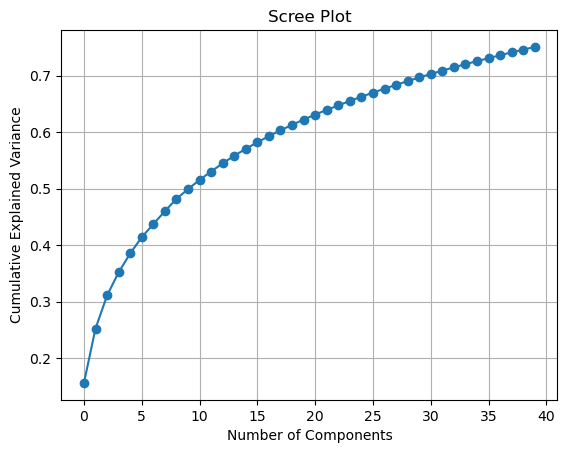

In [169]:
# After fitting PCA
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative variance explained:", np.cumsum(pca.explained_variance_ratio_))

# Scree plot
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

erqk_ealpe       0.997840
hail_expa        0.990836
swnd_expa        0.990836
agrivalue        0.990836
drgt_exp_area    0.980406
cwav_exp_area    0.980406
hail_exp_area    0.980406
erqk_exp_area    0.980406
hwav_exp_area    0.980406
wntw_exp_area    0.980406
dtype: float64


,index,0,field_name
field_alias,,,
Ear - Exp Ann Los - Pop Equ,erqk_ealpe,0.997840,erqk_ealpe
Hail - Exposure - Agricultural Value,hail_expa,0.990836,hail_expa
Strong Wind - Exposure - Agricultural Value,swnd_expa,0.990836,swnd_expa
Agricultural Value ($),agrivalue,0.990836,agrivalue
Drought - Exposure - Impacted Area (sq mi),drgt_exp_area,0.980406,drgt_exp_area
Cold Wave - Exposure - Impacted Area (sq mi),cwav_exp_area,0.980406,cwav_exp_area
Hail - Exposure - Impacted Area (sq mi),hail_exp_area,0.980406,hail_exp_area
Earthquake - Exposure - Impacted Area (sq mi),erqk_exp_area,0.980406,erqk_exp_area
Heat Wave - Exposure - Impacted Area (sq mi),hwav_exp_area,0.980406,hwav_exp_area


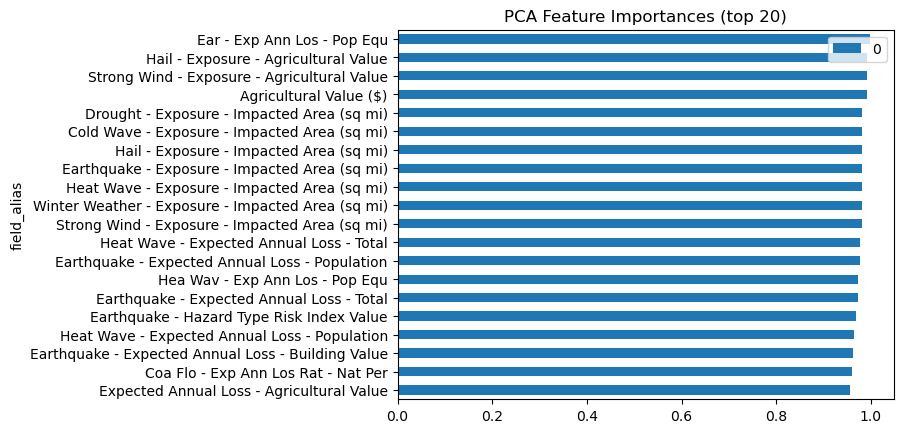

In [170]:
important_features = (
    loadings.abs()
    .sum(axis=1)  # total contribution across PCs
    .sort_values(ascending=False)
)
# important_features = pd.DataFrame(important_features).reset_index()
print(important_features.head(10))
plot_importance(important_features, "PCA Feature Importances (top 20)")

## Correlation

In [67]:
corr = nri_hpi.corr(numeric_only=True)
print(corr)

           avln_alrb  cfld_alrb  cwav_alrb  erqk_alrb  hail_alrb  hwav_alrb  \
avln_alrb   1.000000  -0.004760   0.019705   0.053740   0.118662  -0.001310   
cfld_alrb  -0.004760   1.000000   0.012090  -0.011024  -0.014124  -0.015164   
cwav_alrb   0.019705   0.012090   1.000000  -0.011277   0.327545   0.003832   
erqk_alrb   0.053740  -0.011024  -0.011277   1.000000   0.000428   0.072669   
hail_alrb   0.118662  -0.014124   0.327545   0.000428   1.000000   0.225925   
hwav_alrb  -0.001310  -0.015164   0.003832   0.072669   0.225925   1.000000   
hrcn_alrb  -0.012200   0.222245   0.024186   0.012126  -0.025555   0.004763   
istm_alrb  -0.009023   0.009891   0.168325   0.052974   0.162800   0.142637   
lnds_alrb   0.154824  -0.001805   0.041032   0.237995   0.042777   0.083034   
ltng_alrb   0.005480   0.055508   0.209802   0.051106   0.300249   0.230683   
rfld_alrb  -0.000761   0.049834   0.076583   0.049823   0.041500   0.028623   
swnd_alrb   0.053302   0.014428   0.368318   0.05527

In [68]:
strong_corr = corr[(corr.abs() > 0.5) & (corr.abs() < 1)]
strong_corr = strong_corr.dropna(how="all", axis=0).dropna(how="all", axis=1)

print(strong_corr.dropna(how="all", axis=0).dropna(how="all", axis=1).reset_index())

       index  hrcn_alrb  ltng_alrb  swnd_alrb  trnd_alrb  alr_valb  alr_valp
0  hrcn_alrb        NaN        NaN        NaN        NaN  0.851866       NaN
1  ltng_alrb        NaN        NaN        NaN   0.626957       NaN       NaN
2  swnd_alrb        NaN        NaN        NaN   0.597736       NaN       NaN
3  trnd_alrb        NaN   0.626957   0.597736        NaN       NaN  0.634883
4   alr_valb   0.851866        NaN        NaN        NaN       NaN  0.533546
5   alr_valp        NaN        NaN        NaN   0.634883  0.533546       NaN


In [69]:
"statefips" in nri_dictionary["field_name"].to_list()

True

In [70]:
corr_merged = corr.reset_index().merge(
    nri_dictionary[["field_name", "field_alias"]],
    left_on="index",
    right_on="field_name",
    how="left",
)
corr_merged["field_alias"] = corr_merged["field_alias"].fillna(corr_merged["index"])
corr_merged = corr_merged.set_index("field_alias")
corr_merged = corr_merged.drop(columns="index")
list_field_names = nri_dictionary["field_name"].to_list()
corr_merged.columns = [
    (
        nri_dictionary.loc[nri_dictionary["field_name"] == x, "field_alias"].iloc[0]
        if x in list_field_names
        else x
    )
    for x in corr_merged.columns
]
corr_merged.drop(["field_name"], axis=1, inplace=True)
corr_merged

,Avalanche - Expected Annual Loss Rate - Building,Coa Flo - Exp Ann Los Rat - Bui,Cold Wave - Expected Annual Loss Rate - Building,Earthquake - Expected Annual Loss Rate - Building,Hail - Expected Annual Loss Rate - Building,Heat Wave - Expected Annual Loss Rate - Building,Hurricane - Expected Annual Loss Rate - Building,Ice Storm - Expected Annual Loss Rate - Building,Landslide - Expected Annual Loss Rate - Building,Lightning - Expected Annual Loss Rate - Building,Riv Flo - Exp Ann Los Rat - Bui,Strong Wind - Expected Annual Loss Rate - Building,Tornado - Expected Annual Loss Rate - Building,Tsunami - Expected Annual Loss Rate - Building,Vol Act - Exp Ann Los Rat - Bui,Wildfire - Expected Annual Loss Rate - Building,Win Wea - Exp Ann Los Rat - Bui,Expected Annual Loss Rate - Building - Composite,Expected Annual Loss Rate - Population - Composite,Exp Ann Los Rat - Agr - Com
field_alias,,,,,,,,,,,,,,,,,,,,
Avalanche - Expected Annual Loss Rate - Building,1.000000,-0.004760,0.019705,0.053740,0.118662,-0.001310,-0.012200,-0.009023,0.154824,0.005480,-0.000761,0.053302,0.005389,-0.001090,0.033446,0.277057,0.046598,0.074076,0.105960,0.005019
Coa Flo - Exp Ann Los Rat - Bui,-0.004760,1.000000,0.012090,-0.011024,-0.014124,-0.015164,0.222245,0.009891,-0.001805,0.055508,0.049834,0.014428,0.014329,-0.000868,0.003022,0.016106,-0.010777,0.291494,0.101838,0.125138
Cold Wave - Expected Annual Loss Rate - Building,0.019705,0.012090,1.000000,-0.011277,0.327545,0.003832,0.024186,0.168325,0.041032,0.209802,0.076583,0.368318,0.267208,-0.007239,-0.008605,0.134638,0.378754,0.142808,0.238771,0.126223
Earthquake - Expected Annual Loss Rate - Building,0.053740,-0.011024,-0.011277,1.000000,0.000428,0.072669,0.012126,0.052974,0.237995,0.051106,0.049823,0.055279,0.086369,0.065055,0.217551,0.127671,0.042451,0.319426,0.409062,0.312283
Hail - Expected Annual Loss Rate - Building,0.118662,-0.014124,0.327545,0.000428,1.000000,0.225925,-0.025555,0.162800,0.042777,0.300249,0.041500,0.427810,0.455795,-0.007818,-0.013561,0.134608,0.223461,0.160041,0.303796,0.121781
Heat Wave - Expected Annual Loss Rate - Building,-0.001310,-0.015164,0.003832,0.072669,0.225925,1.000000,0.004763,0.142637,0.083034,0.230683,0.028623,0.236399,0.413259,-0.006274,0.054707,0.024524,0.205825,0.109413,0.334783,0.049079
Hurricane - Expected Annual Loss Rate - Building,-0.012200,0.222245,0.024186,0.012126,-0.025555,0.004763,1.000000,0.005475,-0.016448,0.275197,0.217130,-0.023348,0.101673,0.003959,-0.009869,0.089191,-0.022966,0.851866,0.249459,0.316440
Ice Storm - Expected Annual Loss Rate - Building,-0.009023,0.009891,0.168325,0.052974,0.162800,0.142637,0.005475,1.000000,0.061458,0.279755,0.043956,0.297805,0.317391,-0.006808,-0.009040,0.039646,0.309115,0.137230,0.325069,0.078919
Landslide - Expected Annual Loss Rate - Building,0.154824,-0.001805,0.041032,0.237995,0.042777,0.083034,-0.016448,0.061458,1.000000,0.118968,0.057684,0.083619,0.099412,0.012015,0.158151,0.317166,0.037348,0.156194,0.204529,0.102922


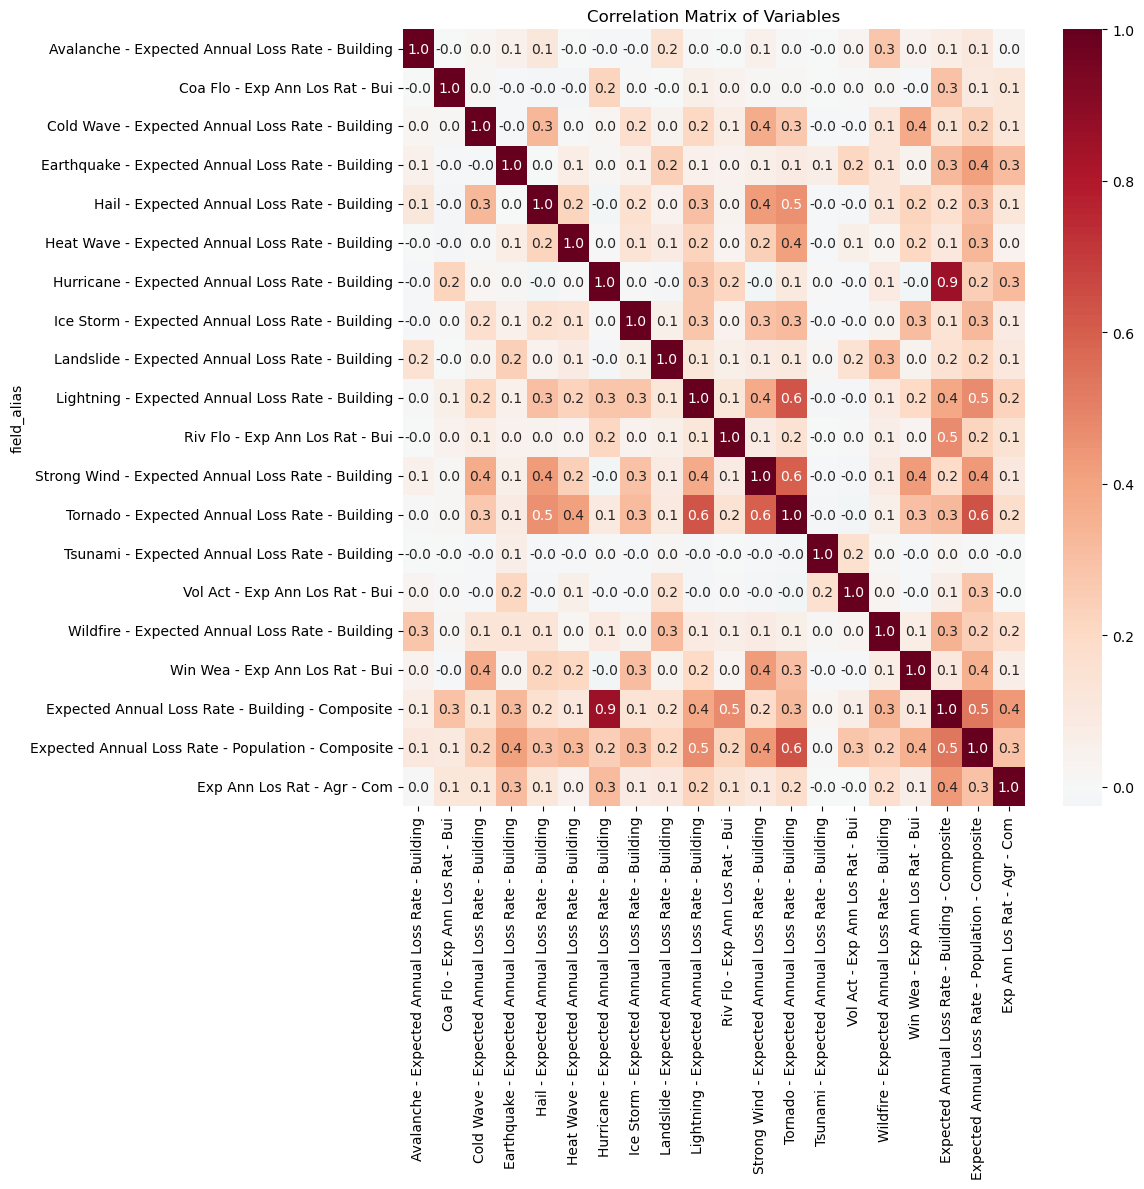

In [153]:
plt.figure(figsize=(12, 12))
sns.heatmap(
    corr_merged,
    # .drop(
    #     columns=["State FIPS Code", "County FIPS Code", "State-County FIPS Code"]
    # ).iloc[3:22, 3:22],
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".1f",
)
plt.title("Correlation Matrix of Variables")
plt.tight_layout()
plt.show()

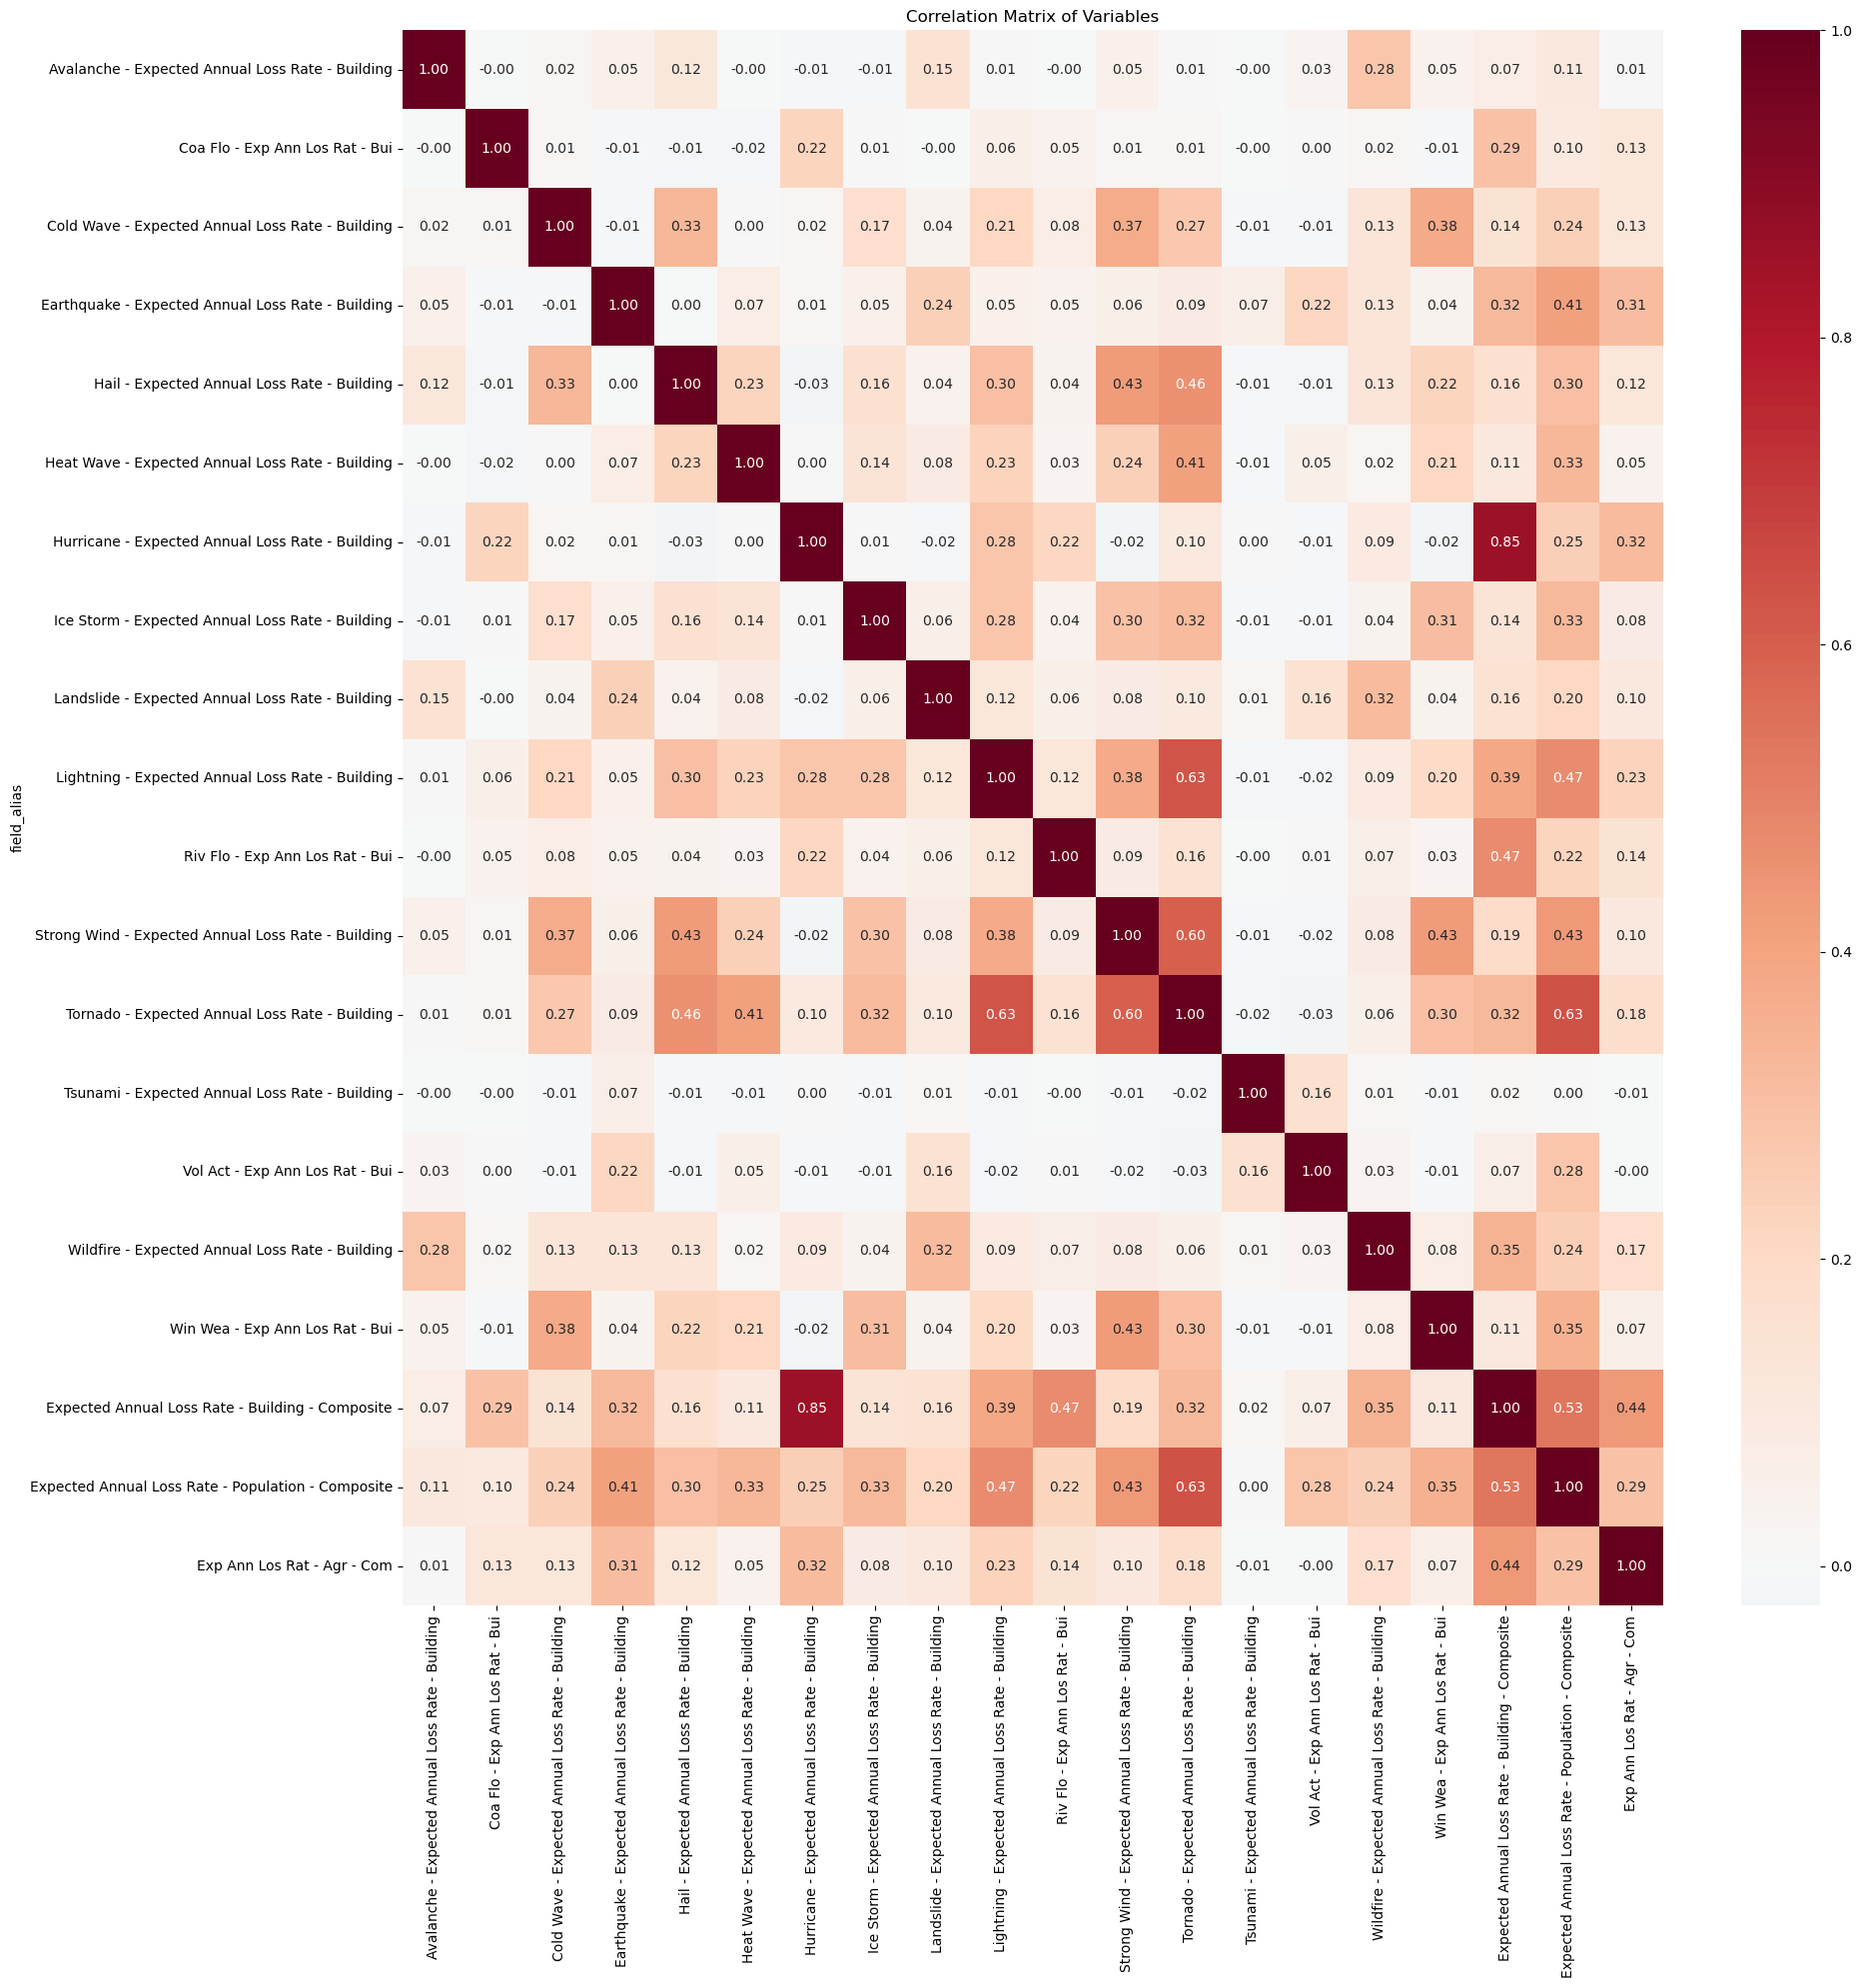

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_merged,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f",
    # corr_merged.iloc[:40, 41:80], annot=True, cmap="RdBu_r", center=0, fmt=".2f"
)
plt.title("Correlation Matrix of Variables")
plt.tight_layout()
plt.show()

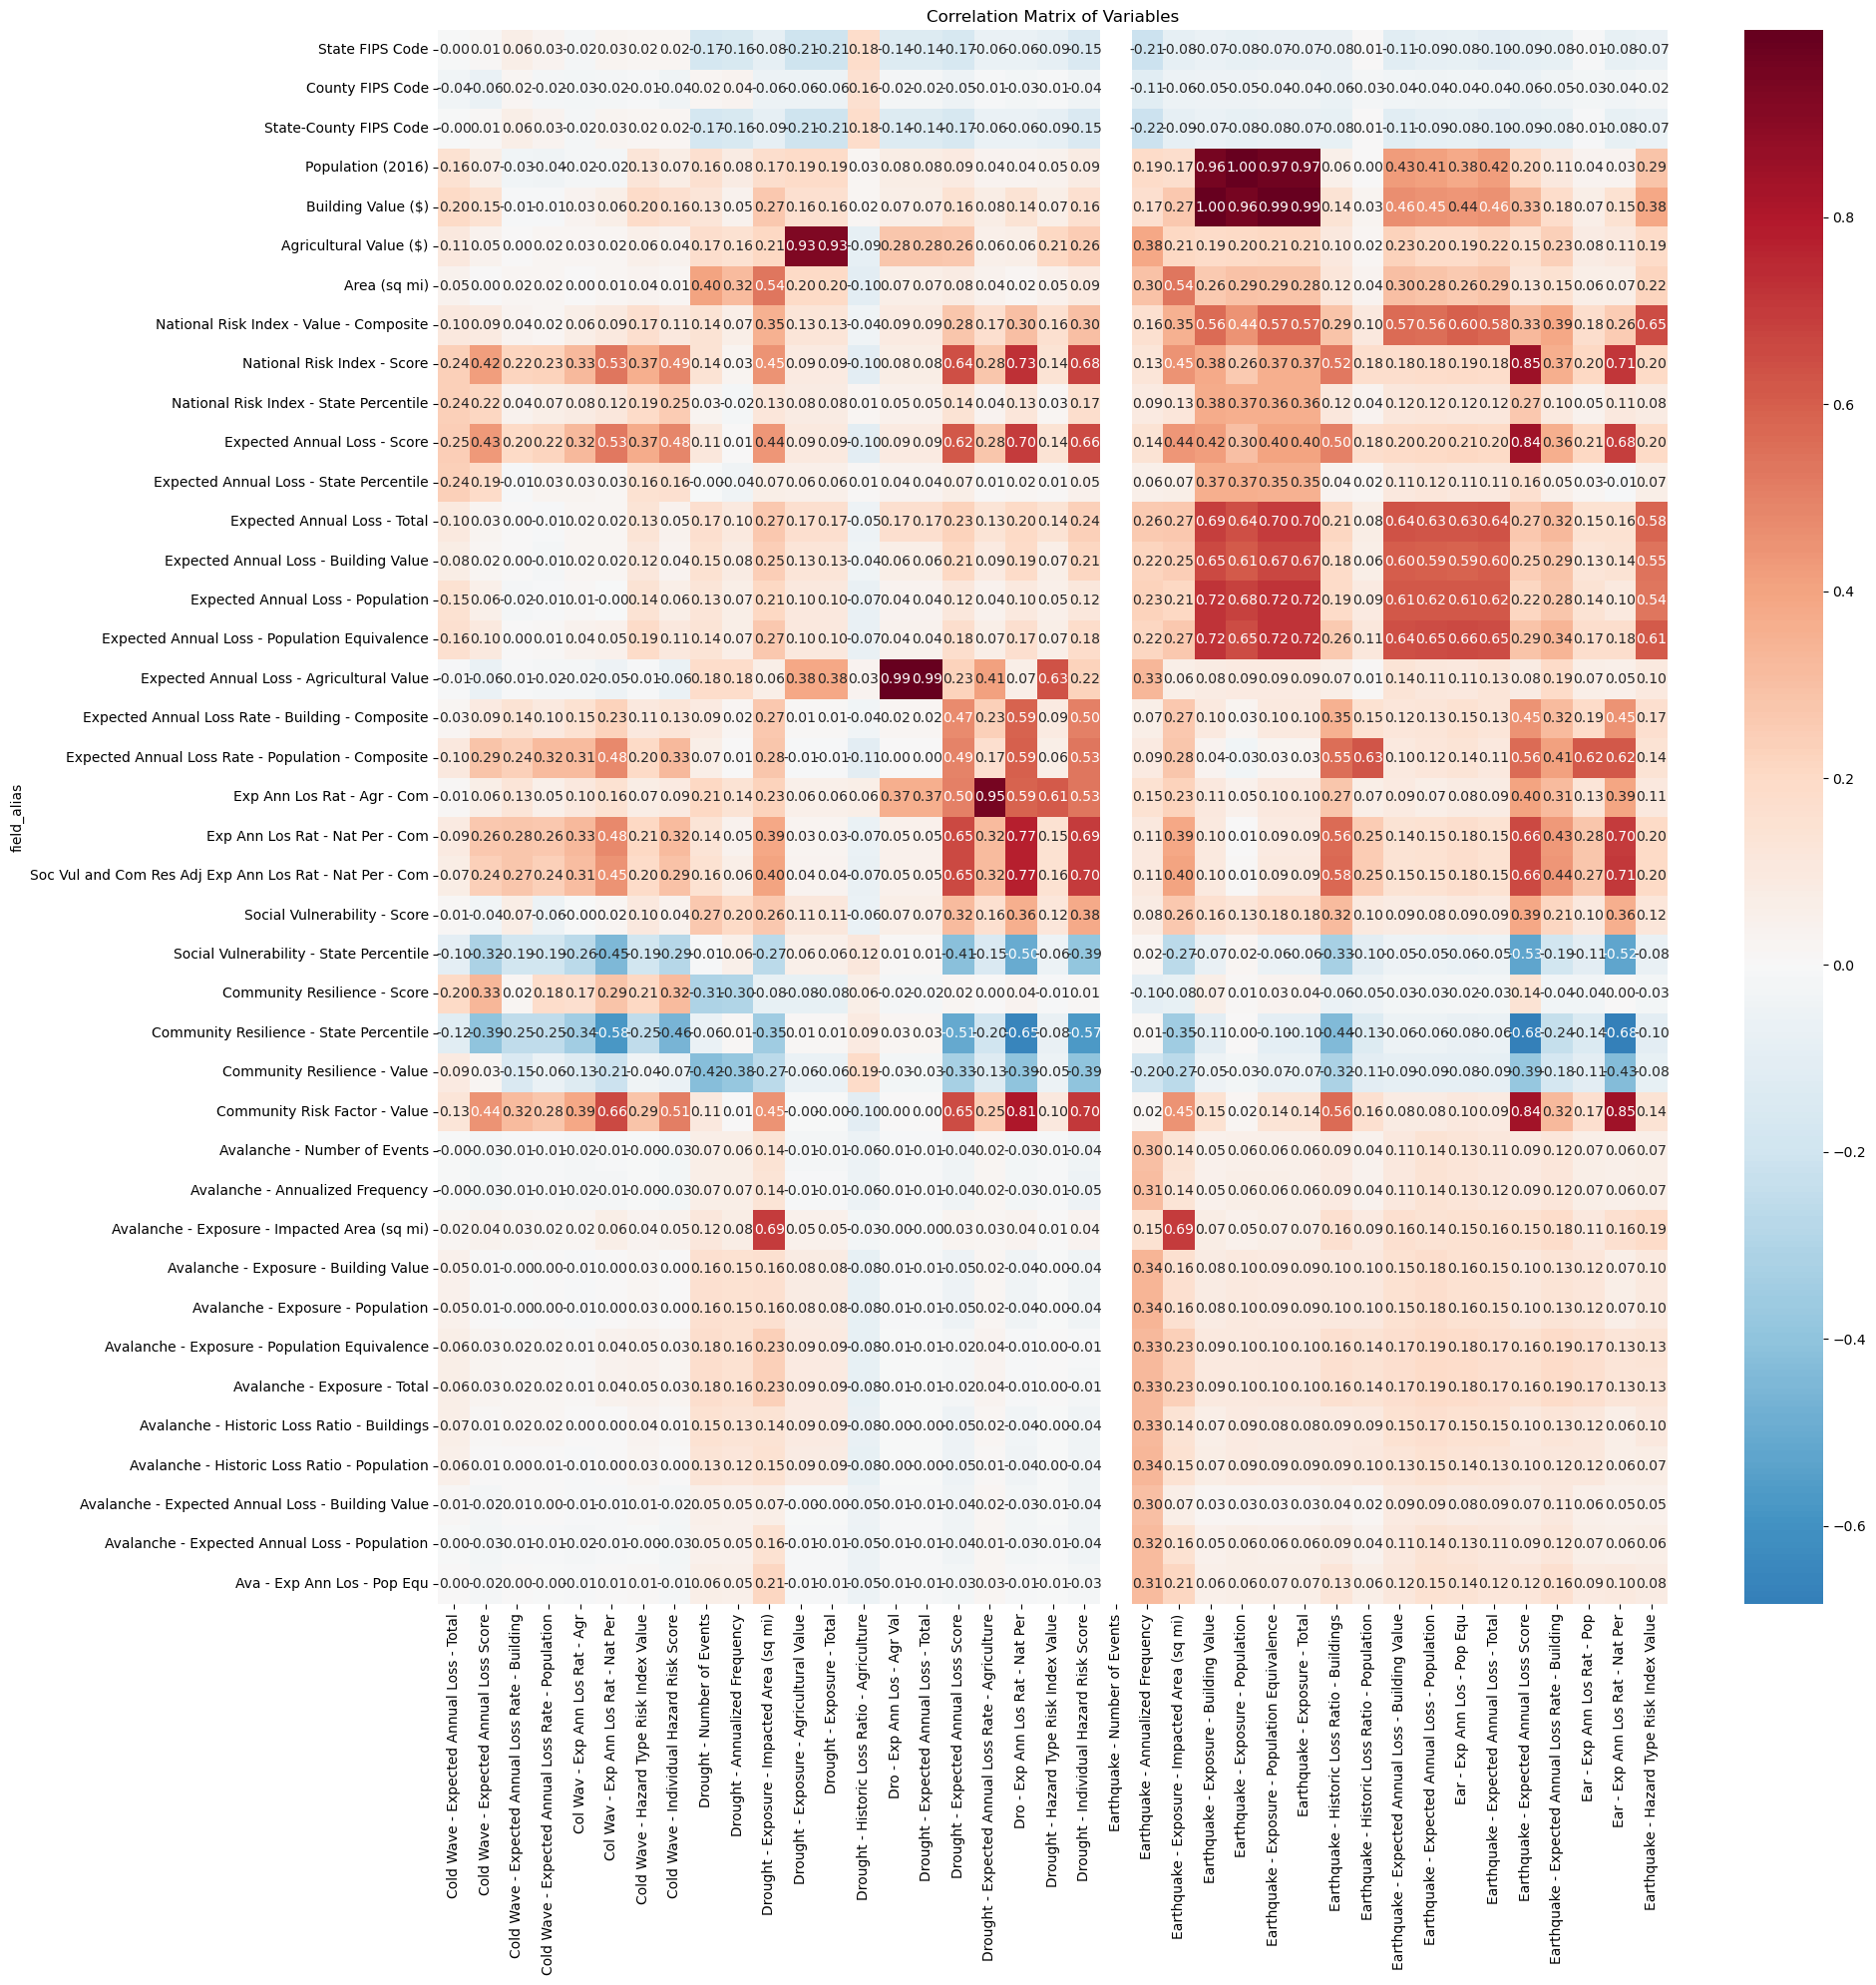

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_merged.iloc[:40, 81:120], annot=True, cmap="RdBu_r", center=0, fmt=".2f"
)
plt.title("Correlation Matrix of Variables")
plt.tight_layout()
plt.show()

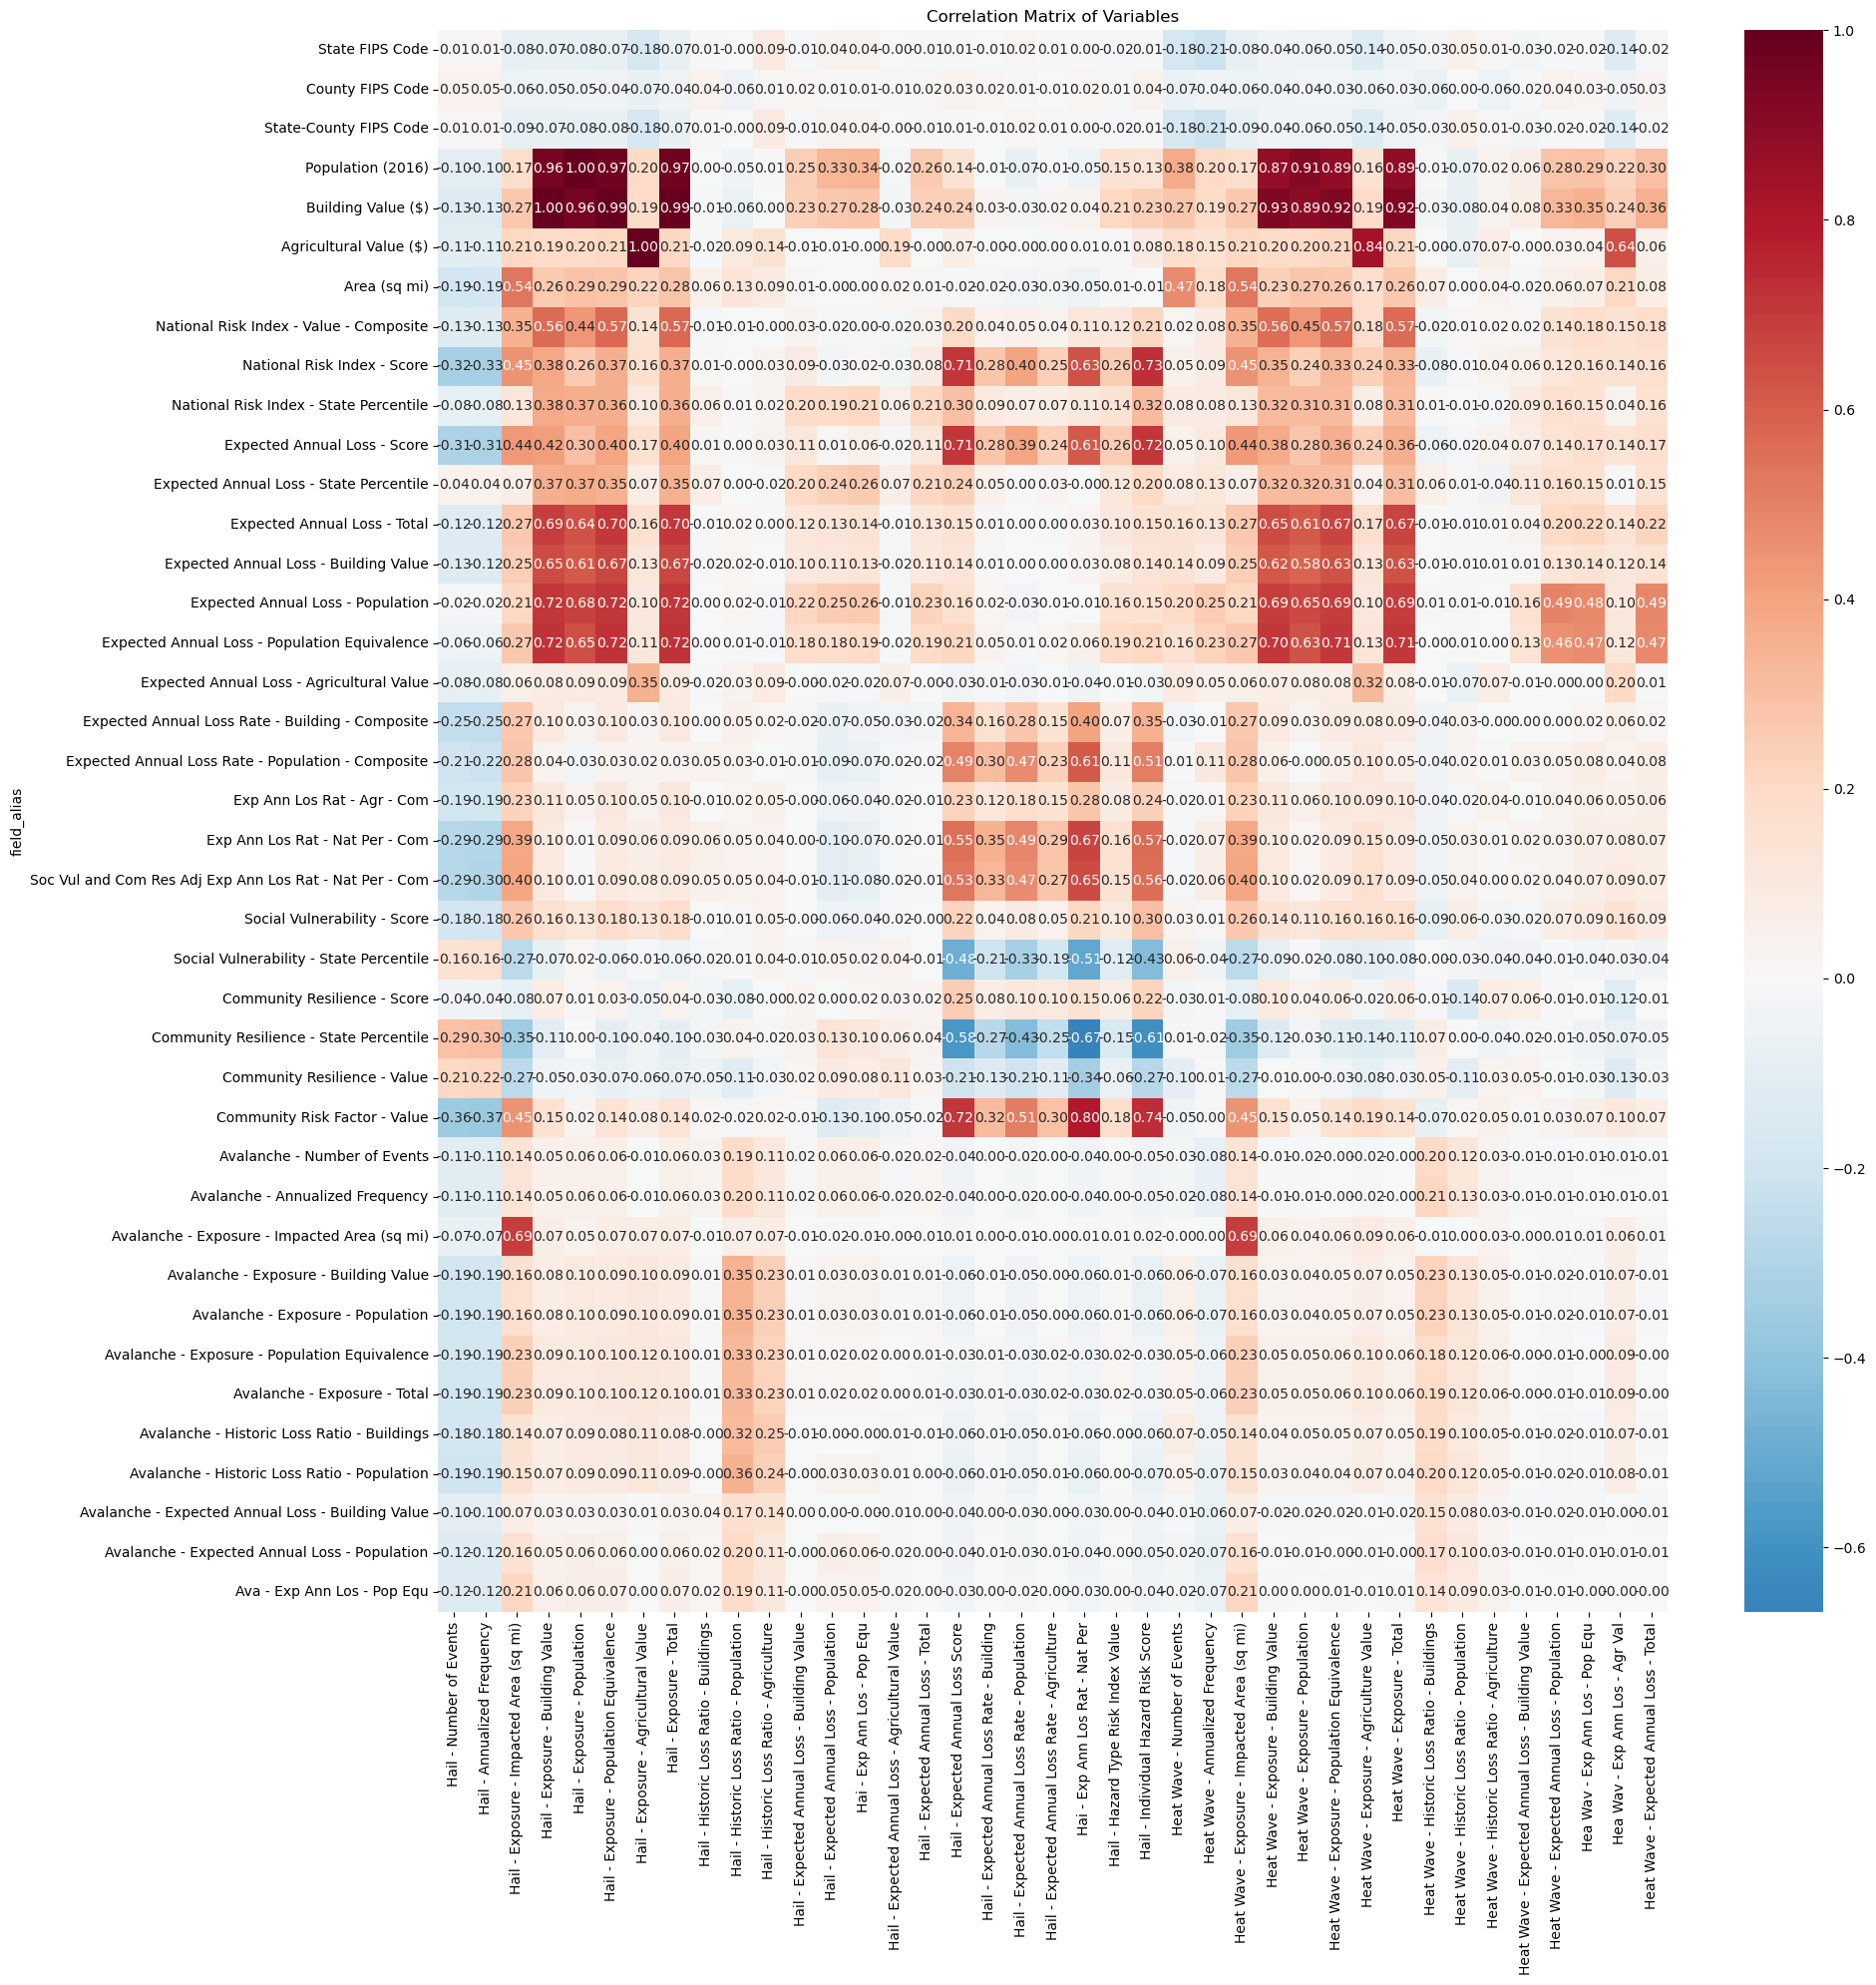

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(
    corr_merged.iloc[:40, 121:160], annot=True, cmap="RdBu_r", center=0, fmt=".2f"
)
plt.title("Correlation Matrix of Variables")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

X = nri_hpi.select_dtypes(include="number").dropna()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

labels = nri_hpi["state"] if "state" in nri_hpi.columns else None

tsne = TSNE(
    n_components=2,  # 2D output
    perplexity=30,  # typical: 5–50 (tunes local/global balance)
    n_iter=1000,  # number of optimization iterations
    random_state=42,
    learning_rate="auto",
)

X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])

X_pca = PCA(n_components=30).fit_transform(X_scaled)
X_tsne = TSNE(
    n_components=2, perplexity=40, n_iter=1000, random_state=42
).fit_transform(X_pca)


plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=tsne_df, x="TSNE1", y="TSNE2", hue="label", palette="tab10", alpha=0.7
)
plt.title("t-SNE Visualization of Features")
plt.show()

ValueError: Found array with 0 sample(s) (shape=(0, 407)) while a minimum of 1 is required by StandardScaler.